In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori

In [7]:
df = pd.read_csv("OnlineRetail.csv", encoding='latin-1')

In [8]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [9]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [10]:
df.dropna(inplace=True)

In [11]:
df = df[df['Quantity'] > 0]

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
basket = (df.groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum().unstack().fillna(0))

basket.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536366,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536367,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536368,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
536369,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
basket = (basket > 0)

In [23]:
frequent_items = apriori(basket, min_support=0.02, use_colnames=True)
frequent_items.head()

,support,itemsets
0,0.021688,(3 STRIPEY MICE FELTCRAFT)
1,0.039167,(6 RIBBONS RUSTIC CHARM)
2,0.025140,(60 CAKE CASES VINTAGE CHRISTMAS)
3,0.035445,(60 TEATIME FAIRY CAKE CASES)
4,0.027028,(72 SWEETHEART FAIRY CAKE CASES)


In [26]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_items, metric="lift", min_threshold=1)
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE GREEN),0.047313,0.042566,0.028593,0.604333,14.197612,1.0,0.026579,2.419798,0.975731,0.466549,0.586742,0.638035
1,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED ),0.042566,0.047313,0.028593,0.671736,14.197612,1.0,0.026579,2.902200,0.970892,0.466549,0.655434,0.638035
2,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE PINK),0.047313,0.033071,0.021364,0.451539,13.653725,1.0,0.019799,1.762987,0.972786,0.361974,0.432781,0.548771
3,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE RED ),0.033071,0.047313,0.021364,0.646003,13.653725,1.0,0.019799,2.691230,0.958457,0.361974,0.628423,0.548771
4,(SPACEBOY LUNCH BOX ),(DOLLY GIRL LUNCH BOX),0.037980,0.033233,0.022874,0.602273,18.122934,1.0,0.021612,2.430729,0.982122,0.473214,0.588601,0.645292


In [27]:
strong_rules = rules[(rules['lift'] > 1.5) & (rules['confidence'] > 0.5)]
strong_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE GREEN),0.047313,0.042566,0.028593,0.604333,14.197612,1.0,0.026579,2.419798,0.975731,0.466549,0.586742,0.638035
1,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED ),0.042566,0.047313,0.028593,0.671736,14.197612,1.0,0.026579,2.902200,0.970892,0.466549,0.655434,0.638035
3,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE RED ),0.033071,0.047313,0.021364,0.646003,13.653725,1.0,0.019799,2.691230,0.958457,0.361974,0.628423,0.548771
4,(SPACEBOY LUNCH BOX ),(DOLLY GIRL LUNCH BOX),0.037980,0.033233,0.022874,0.602273,18.122934,1.0,0.021612,2.430729,0.982122,0.473214,0.588601,0.645292
5,(DOLLY GIRL LUNCH BOX),(SPACEBOY LUNCH BOX ),0.033233,0.037980,0.022874,0.688312,18.122934,1.0,0.021612,3.086480,0.977300,0.473214,0.676006,0.645292
6,(GARDENERS KNEELING PAD CUP OF TEA ),(GARDENERS KNEELING PAD KEEP CALM ),0.034258,0.040785,0.024978,0.729134,17.877282,1.0,0.023581,3.541286,0.977552,0.498922,0.717617,0.670784
7,(GARDENERS KNEELING PAD KEEP CALM ),(GARDENERS KNEELING PAD CUP OF TEA ),0.040785,0.034258,0.024978,0.612434,17.877282,1.0,0.023581,2.491813,0.984204,0.498922,0.598686,0.670784
8,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.029996,0.037279,0.024817,0.827338,22.193256,1.0,0.023698,5.575760,0.984471,0.584498,0.820652,0.746520
9,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.037279,0.029996,0.024817,0.665702,22.193256,1.0,0.023698,2.901615,0.991919,0.584498,0.655364,0.746520
10,(GREEN REGENCY TEACUP AND SAUCER),(REGENCY CAKESTAND 3 TIER),0.037279,0.091929,0.020177,0.541245,5.887623,1.0,0.016750,1.979422,0.862298,0.185057,0.494802,0.380364


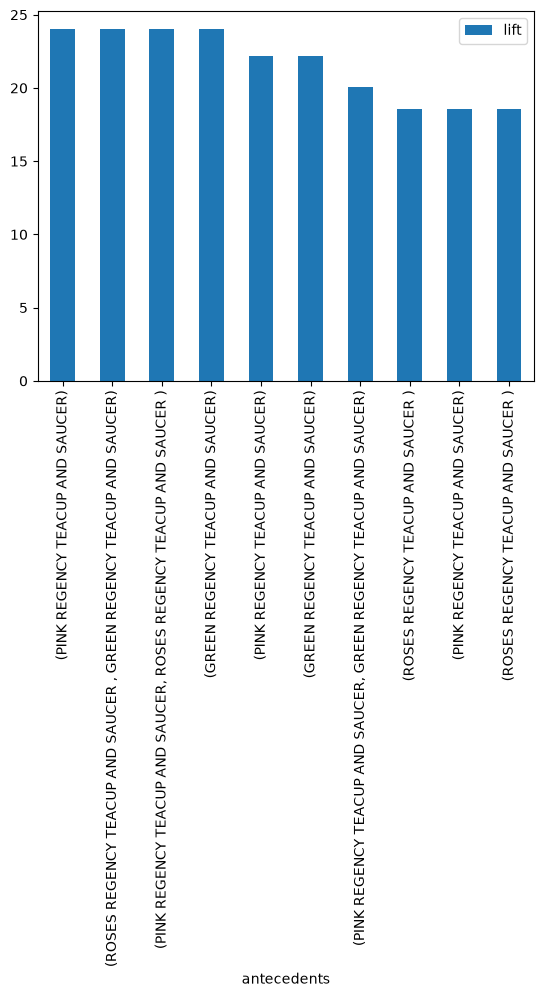

In [30]:
strong_rules.sort_values('lift', ascending=False).head(10).plot(
    x='antecedents', y='lift', kind='bar'
)
plt.show()